# 🚗 AI-Powered Car Recommendation System using NLP
### Semantic (Embedding-Based) Recommendation Engine — Real Dataset

**Author:** _(add your name)_
**Course project:** Building an AI-powered recommendation system that suggests the
best-fit car for a user based on personal preferences (budget, usage, fuel efficiency,
performance) by matching car specifications to the user's needs using NLP.

---

**Dataset:** *Comprehensive Vehicle Specifications Dataset* (Kaggle, Adarsh, 2025) —
https://www.kaggle.com/datasets/adarsh1077/comprehensive-vehicle-specifications-dataset
(504 real car listings scraped from Indian automotive portals; bundled locally as
`structured_car_data_cleaned.json`).

This notebook:
1. Loads the real, raw scraped dataset (JSON)
2. **Diagnoses and repairs a real data-quality defect**: many rows have their fields
   column-shifted (e.g. a car's mileage value appears under the `fuel` key instead of
   `mileage`), a common artifact of scraping pages with inconsistent field counts
3. Recovers the true values using **content-pattern extraction** (regex matched against
   the full record text, independent of which key each value landed under) rather than
   trusting the (unreliable) field labels
4. Converts structured specs into natural-language car "profiles"
5. Parses free-text user preferences with NLP (keyword + constraint extraction)
6. Embeds car profiles and user queries with a Sentence-BERT model (TF-IDF fallback if
   offline) and ranks with a hybrid semantic + constraint score
7. Evaluates and visualizes the recommendations

> Run all cells top-to-bottom in Google Colab.


## 1. Setup — Install & Import Libraries

In [1]:
!pip install -q sentence-transformers pandas scikit-learn matplotlib seaborn


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(42)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the Raw Dataset

Upload `structured_car_data_cleaned.json` to the Colab file browser (left sidebar), or
clone the GitHub repo (it's bundled under `/data`). The loader checks a few common
locations automatically.


In [3]:
DATA_CANDIDATES = [
    "structured_car_data_cleaned.json",
    "data/structured_car_data_cleaned.json",
    "/content/structured_car_data_cleaned.json",
    "/content/data/structured_car_data_cleaned.json",
]


def find_local_data_file():
    for path in DATA_CANDIDATES:
        if os.path.exists(path):
            return path
    return None


data_path = find_local_data_file()
if data_path is None:
    raise FileNotFoundError(
        "structured_car_data_cleaned.json not found. Upload it via the Colab file "
        "browser (Files icon on the left) or clone the GitHub repo, which includes it "
        "under /data."
    )

with open(data_path) as f:
    raw_records = json.load(f)

print(f"Loaded {len(raw_records)} raw records from {data_path}")
raw_records[0]


Loaded 504 raw records from structured_car_data_cleaned.json


{'name': 'Maruti Suzuki Ertiga',
 'price': 'Rs.8.84 - 13.13 Lakh* (View On Road Price)',
 'fuel': 'Petrol/CNG',
 'mileage': '20.51 kmpl',
 'transmission': 'Manual/Automatic',
 'cc': '1462 cc',
 'power': '101.64 bhp',
 'safety': '1 Star Safety',
 'seats': None,
 'type': 'car'}

## 3. Data Quality Diagnosis — Column-Shifted Rows

Inspecting the raw JSON reveals a real scraping defect: for a meaningful subset of
rows, values are shifted into the wrong key. For example:

```
{'name': 'Aston Martin Vantage',
 'price': 'Rs.3.99 Cr* (View On Road Price)',
 'fuel': '7 kmpl',            # <- this is actually the mileage value
 'mileage': '3998 cc',        # <- this is actually the engine displacement
 'transmission': '656 bhp',   # <- this is actually the engine power
 'cc': '2 Seats',             # <- this is actually the seat count
 'power': None, 'safety': None, 'seats': None}
```

This happens when a scraper assumes a fixed column order per page but some pages are
missing a field (e.g. no listed transmission), silently shifting every subsequent value
left by one position. Trusting field **labels** here would corrupt the dataset (e.g.
treating "7 kmpl" as a fuel type). Instead we extract values **by content pattern**
(regex) from the concatenation of all fields in a row, which is robust to shifting
because each value's unit/keyword (`cc`, `bhp`, `kmpl`, `Seats`, `Star Safety`, `Rs.`)
identifies what it actually is, regardless of which key it was filed under.


In [4]:
def field_blob(record):
    """Concatenate all non-null field values into one text blob for pattern search."""
    return " | ".join(str(v) for v in record.values() if v)


# Demonstrate the defect on the Aston Martin Vantage example
example = next(r for r in raw_records if r.get("name") == "Aston Martin Vantage")
print("Raw record (note the shifted fields):")
print(json.dumps(example, indent=2))


Raw record (note the shifted fields):
{
  "name": "Aston Martin Vantage",
  "price": "Rs.3.99 Cr* (View On Road Price)",
  "fuel": "7 kmpl",
  "mileage": "3998 cc",
  "transmission": "656 bhp",
  "cc": "2 Seats",
  "power": null,
  "safety": null,
  "seats": null,
  "type": "car"
}


## 4. Content-Pattern Extraction Pipeline

In [5]:
USD_PER_INR = 1 / 83.0  # approximate INR->USD conversion rate (adjust as needed)


def extract_price_usd(text):
    m = re.search(r"Rs\.?\s*([\d,.]+)\s*(?:-\s*([\d,.]+)\s*)?(Lakh|Cr)", text, re.I)
    if not m:
        return np.nan
    lo = float(m.group(1).replace(",", ""))
    hi = float(m.group(2).replace(",", "")) if m.group(2) else lo
    multiplier = 10_000_000 if m.group(3).lower() == "cr" else 100_000  # INR
    avg_inr = ((lo + hi) / 2) * multiplier
    return round(avg_inr * USD_PER_INR, 2)


def extract_float(pattern, text):
    m = re.search(pattern, text, re.I)
    return float(m.group(1)) if m else np.nan


def extract_keyword_by_position(keywords, text):
    """Return the keyword that appears EARLIEST in the text (the true primary value),
    not the first keyword checked — avoids biasing e.g. 'Petrol/CNG' towards CNG."""
    matches = []
    for kw in keywords:
        m = re.search(rf"\b{kw}\b", text, re.I)
        if m:
            matches.append((m.start(), kw))
    return sorted(matches)[0][1] if matches else None


def extract_safety_star(text):
    m = re.search(r"(\d)\s*Star Safety", text, re.I)
    return int(m.group(1)) if m else np.nan


def extract_seats(text):
    nums = re.findall(r"(\d+)\s*Seats", text, re.I)
    return int(max(int(n) for n in nums)) if nums else np.nan


KNOWN_MULTIWORD_MAKES = [
    "Maruti Suzuki", "Aston Martin", "Land Rover", "Mercedes-Benz", "Mercedes Benz",
    "Rolls-Royce", "Rolls Royce", "Alfa Romeo", "MG Motor", "San Motors",
]


def extract_make(name):
    for mk in KNOWN_MULTIWORD_MAKES:
        if name.startswith(mk):
            return mk
    return name.split(" ")[0]


def parse_record(r):
    text = field_blob(r)
    name = r.get("name", "")
    make = extract_make(name)
    return {
        "name": name,
        "make": make,
        "model": name[len(make):].strip() or name,
        "price_usd": extract_price_usd(text),
        "engine_cc": extract_float(r"(\d{2,5})\s*cc", text),
        "engine_power_hp": extract_float(r"([\d.]+)\s*bhp", text),
        "mileage_kmpl": extract_float(r"([\d.]+)\s*kmpl", text),
        "fuel_type": extract_keyword_by_position(
            ["Electric", "Hybrid", "CNG", "LPG", "Diesel", "Petrol"], text
        ),
        "transmission": extract_keyword_by_position(
            ["Automatic", "Manual", "CVT", "AMT", "DCT"], text
        ),
        "safety_rating": extract_safety_star(text),
        "seats": extract_seats(text),
    }


parsed_rows = [parse_record(r) for r in raw_records]
df_parsed = pd.DataFrame(parsed_rows)

print("Field completeness after extraction (% non-null):")
print((df_parsed.notna().mean() * 100).round(1))
df_parsed.head(10)


Field completeness after extraction (% non-null):
name               100.0
make               100.0
model              100.0
price_usd           99.6
engine_cc           71.8
engine_power_hp     57.9
mileage_kmpl        68.3
fuel_type           66.5
transmission        35.5
safety_rating       22.2
seats               57.7
dtype: float64


,name,make,model,price_usd,engine_cc,engine_power_hp,mileage_kmpl,fuel_type,transmission,safety_rating,seats
0,Maruti Suzuki Ertiga,Maruti Suzuki,Ertiga,13234.94,1462.0,101.64,20.51,Petrol,Manual,1.0,NaN
1,Maruti Suzuki Swift,Maruti Suzuki,Swift,9716.87,1197.0,80.46,25.75,Petrol,Manual,4.0,NaN
2,Maruti Suzuki Dzire,Maruti Suzuki,Dzire,10259.04,1197.0,80.00,25.71,Petrol,Manual,5.0,NaN
3,Maruti Suzuki Brezza,Maruti Suzuki,Brezza,13753.01,1462.0,101.64,19.89,Petrol,Manual,4.0,NaN
4,Maruti Suzuki FRONX,Maruti Suzuki,FRONX,12397.59,1197.0,98.69,22.89,Petrol,Manual,NaN,5.0
5,Maruti Suzuki Baleno,Maruti Suzuki,Baleno,10012.05,1197.0,88.50,22.94,Petrol,Manual,NaN,5.0
6,Maruti Suzuki Grand Vitara,Maruti Suzuki,Grand Vitara,19337.35,1490.0,101.64,27.97,Petrol,Manual,NaN,5.0
7,Maruti Suzuki Wagon R,Maruti Suzuki,Wagon R,7897.59,1197.0,88.50,25.19,Petrol,Manual,1.0,NaN
8,Maruti Suzuki Alto K10,Maruti Suzuki,Alto K10,6289.16,998.0,65.71,24.90,Petrol,Manual,2.0,NaN
9,Maruti Suzuki Celerio,Maruti Suzuki,Celerio,7837.35,998.0,65.71,26.68,Petrol,Manual,NaN,5.0


## 5. Cleaning & Imputation

Even after correct extraction, several fields remain genuinely missing in the source
(the scraper simply never captured them for some listings — the shift shows they existed
in a *different* position for other rows, but for many rows the value is not present
anywhere in the record). We apply standard, documented imputation:

- Rows with no recoverable **price** are dropped (price is essential for budget matching
  and cannot be safely imputed for a specific car).
- Missing **numeric specs** (engine cc, power, mileage, seats, safety rating) are
  imputed with the dataset median — a simplification noted as a limitation in the report,
  since it does not account for make/segment differences.
- Missing **categorical fields** (fuel type, transmission) are labeled `"Unknown"`
  rather than imputed, since guessing a wrong category (e.g. Electric vs Petrol) would
  actively mislead the recommender.


In [6]:
df_clean = df_parsed.dropna(subset=["price_usd"]).copy()

numeric_cols = ["engine_cc", "engine_power_hp", "mileage_kmpl", "seats", "safety_rating"]
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean["seats"] = df_clean["seats"].round().clip(2, 9).astype(int)
df_clean["safety_rating"] = df_clean["safety_rating"].round().clip(1, 5).astype(int)

df_clean["fuel_type"] = df_clean["fuel_type"].fillna("Unknown")
df_clean["transmission"] = df_clean["transmission"].fillna("Unknown")

# Clip unrealistic outliers (winsorize at 1st/99th percentile) on continuous fields
for col in ["price_usd", "mileage_kmpl", "engine_power_hp", "engine_cc"]:
    lo, hi = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(lo, hi)

df_clean = df_clean.reset_index(drop=True)
df_clean["car_id"] = df_clean.index

print(f"Rows before cleaning: {len(df_parsed)}  |  after cleaning: {len(df_clean)}")
df_clean.describe(include="number")


Rows before cleaning: 504  |  after cleaning: 502


,price_usd,engine_cc,engine_power_hp,mileage_kmpl,safety_rating,seats,car_id
count,5.020000e+02,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000
mean,9.791414e+04,2098.394900,233.012328,16.400536,4.778884,4.958167,250.500000
std,1.878710e+05,1035.379859,162.358925,4.371361,0.776985,0.964563,145.059183
min,4.325300e+03,998.000000,41.567900,5.801000,1.000000,2.000000,0.000000
25%,1.060542e+04,1483.750000,160.920000,14.725000,5.000000,5.000000,125.250000
50%,2.124699e+04,1910.000000,185.730000,16.410000,5.000000,5.000000,250.500000
75%,8.418675e+04,1998.000000,201.000000,18.835000,5.000000,5.000000,375.750000
max,1.066235e+06,6493.040000,790.975200,27.125500,5.000000,9.000000,501.000000


## 6. Turning Structured Specs into Natural-Language Car Profiles

Each row is converted into a descriptive sentence so Sentence-BERT can compare it
semantically against a user's free-text request.


In [7]:
def build_car_profile(row):
    return (
        f"{row['make']} {row['model']} is priced at ${row['price_usd']:,.0f}. "
        f"It runs on {row['fuel_type'].lower()} fuel with a "
        f"{row['transmission'].lower()} transmission, has a {row['engine_cc']:.0f}cc "
        f"engine producing {row['engine_power_hp']:.0f} horsepower, achieves "
        f"{row['mileage_kmpl']:.1f} km/l fuel efficiency, seats {row['seats']} people, "
        f"and has a {row['safety_rating']}-star safety rating."
    )

df_clean["car_profile"] = df_clean.apply(build_car_profile, axis=1)
df_clean[["make", "model", "car_profile"]].head(3)


,make,model,car_profile
0,Maruti Suzuki,Ertiga,"Maruti Suzuki Ertiga is priced at $13,235. It ..."
1,Maruti Suzuki,Swift,"Maruti Suzuki Swift is priced at $9,717. It ru..."
2,Maruti Suzuki,Dzire,"Maruti Suzuki Dzire is priced at $10,259. It r..."


## 7. NLP Preference Parser

Extracts *hard* constraints (budget, minimum seats, fuel-type preference) from free
text with rules, while the full sentence is separately embedded to capture *soft*
preferences (style, usage context) that keyword rules would miss.

> **Note:** this dataset does not include a body-type/segment field (SUV, sedan,
> hatchback, etc.), so — unlike a version built on a richer dataset — body type is
> **not** enforced as a hard constraint here. It is documented as a limitation in the
> written report.


In [8]:
FUEL_KEYWORDS = {
    "electric": "Electric", "ev": "Electric",
    "hybrid": "Hybrid",
    "diesel": "Diesel",
    "petrol": "Petrol", "gas": "Petrol", "gasoline": "Petrol",
    "cng": "CNG",
}

WORD_NUMBERS = {
    "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "seven": 7, "eight": 8, "nine": 9,
}


def parse_user_preferences(text):
    text_l = text.lower()
    prefs = {"max_budget": None, "min_seats": None, "fuel_type": None}

    for m in re.finditer(
        r"(under|below|less than|budget of|around|no more than|not more than|"
        r"up to|max(?:imum)? of|max(?:imum)?)\s+\$?\s?(\d[\d,]*)\s?(k)?",
        text_l,
    ):
        amount = float(m.group(2).replace(",", ""))
        if m.group(3) == "k":
            amount *= 1000
        prefs["max_budget"] = amount

    for word, num in WORD_NUMBERS.items():
        text_l = re.sub(rf"\b{word}\b(?=\s?-?\s?seat)", str(num), text_l)

    seat_match = re.search(r"(\d)\s?(-)?\s?seat", text_l)
    if seat_match:
        prefs["min_seats"] = int(seat_match.group(1))
    elif "family" in text_l:
        prefs["min_seats"] = 5

    for kw, val in FUEL_KEYWORDS.items():
        if kw in text_l:
            prefs["fuel_type"] = val
            break

    return prefs


sample_query = "I need a fuel-efficient family car under $15,000 with good safety"
print(parse_user_preferences(sample_query))


{'max_budget': 15000.0, 'min_seats': 5, 'fuel_type': None}


## 8. Embedding Model — Sentence-BERT

Uses `all-MiniLM-L6-v2` when internet is available; automatically falls back to TF-IDF
embeddings otherwise so the pipeline still runs end-to-end offline.


In [9]:
EMBEDDING_BACKEND = None
_tfidf_vectorizer = None
_tfidf_fitted = False

try:
    _st_model = SentenceTransformer("all-MiniLM-L6-v2")
    EMBEDDING_BACKEND = "sentence-transformers (all-MiniLM-L6-v2)"

    def embed_texts(texts):
        return _st_model.encode(
            texts, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False
        )

except Exception as e:
    print(f"[info] Sentence-BERT unavailable ({e}).")
    print("[info] Falling back to TF-IDF embeddings so the pipeline still runs end-to-end.")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import normalize as sk_normalize

    _tfidf_vectorizer = TfidfVectorizer()
    EMBEDDING_BACKEND = "TF-IDF (offline fallback — upgrades automatically to Sentence-BERT when internet is available)"

    def embed_texts(texts):
        global _tfidf_fitted
        if not _tfidf_fitted:
            vecs = _tfidf_vectorizer.fit_transform(texts).toarray()
            _tfidf_fitted = True
        else:
            vecs = _tfidf_vectorizer.transform(texts).toarray()
        return sk_normalize(vecs)

print("Embedding backend in use:", EMBEDDING_BACKEND)

car_embeddings = embed_texts(df_clean["car_profile"].tolist())
print("Embedding matrix shape:", car_embeddings.shape)


[info] Sentence-BERT unavailable (We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.).
[info] Falling back to TF-IDF embeddings so the pipeline still runs end-to-end.
Embedding backend in use: TF-IDF (offline fallback — upgrades automatically to Sentence-BERT when internet is available)


Embedding matrix shape: (502, 928)


## 9. Hybrid Recommendation Engine

In [ ]:
def recommend_cars(user_text, top_k=5, w_semantic=0.7, w_budget=0.3):
    prefs = parse_user_preferences(user_text)

    query_emb = embed_texts([user_text])
    sim_scores = cosine_similarity(query_emb, car_embeddings)[0]

    candidates = df_clean.copy()
    candidates["semantic_score"] = sim_scores

    penalty = np.zeros(len(candidates))
    if prefs["max_budget"]:
        penalty += (candidates["price_usd"] > prefs["max_budget"]) * 0.5
    if prefs["min_seats"]:
        penalty += (candidates["seats"] < prefs["min_seats"]) * 0.3
    if prefs["fuel_type"]:
        penalty += (candidates["fuel_type"] != prefs["fuel_type"]) * 0.2

    if prefs["max_budget"]:
        budget_fit = 1 - (candidates["price_usd"] / prefs["max_budget"]).clip(0, 2) / 2
    else:
        budget_fit = 1 - (candidates["price_usd"] - candidates["price_usd"].min()) / \
                         (candidates["price_usd"].max() - candidates["price_usd"].min() + 1e-9)

    candidates["final_score"] = (
        w_semantic * candidates["semantic_score"] + w_budget * budget_fit - penalty
    )

    # Sort by final_score and deduplicate to ensure diverse results
    sorted_candidates = candidates.sort_values("final_score", ascending=False)
    
    # Keep only the first occurrence of each unique car (by make + model)
    seen = set()
    unique_indices = []
    for idx, row in sorted_candidates.iterrows():
        car_key = (row["make"], row["model"])
        if car_key not in seen:
            seen.add(car_key)
            unique_indices.append(idx)
            if len(unique_indices) >= top_k:
                break
    
    results = sorted_candidates.loc[unique_indices]
    return results[["make", "model", "fuel_type", "transmission", "price_usd",
                     "mileage_kmpl", "engine_power_hp", "seats", "safety_rating",
                     "semantic_score", "final_score"]], prefs


query = "I need a fuel-efficient family car under $15,000 with good safety ratings"
recs, parsed_prefs = recommend_cars(query, top_k=5)
print("Parsed preferences:", parsed_prefs)
recs

Parsed preferences: {'max_budget': 15000.0, 'min_seats': 5, 'fuel_type': None}


,make,model,fuel_type,transmission,price_usd,mileage_kmpl,engine_power_hp,seats,safety_rating,semantic_score,final_score
367,Chevrolet,Aveo U-VA,Petrol,Unknown,6000.0,15.26,185.73,5,5,0.460460,0.562322
400,Daewoo,Matiz,Petrol,Unknown,5000.0,18.50,185.73,5,5,0.364658,0.505261
423,Fiat,Palio,Petrol,Unknown,4325.3,15.50,185.73,5,5,0.242856,0.426746
347,Fiat,Palio,Petrol,Unknown,4325.3,15.50,185.73,5,5,0.242856,0.426746
348,Fiat,Palio D,Diesel,Unknown,4325.3,15.50,185.73,5,5,0.241713,0.425946


## 10. Try Your Own Query

> **Note:** with the TF-IDF fallback backend (no internet), semantic matching only
> catches words that literally appear in the car profiles. The **hard-constraint
> filters** (budget, seats, fuel type) still work correctly regardless of backend,
> since those are rule-based, not embedding-based.


In [11]:
your_query = "high performance sports car, budget around $60,000"  #@param {type:"string"}
recs2, prefs2 = recommend_cars(your_query, top_k=5)
print("Parsed preferences:", prefs2)
recs2


Parsed preferences: {'max_budget': 60000.0, 'min_seats': None, 'fuel_type': None}


,make,model,fuel_type,transmission,price_usd,mileage_kmpl,engine_power_hp,seats,safety_rating,semantic_score,final_score
400,Daewoo,Matiz,Petrol,Unknown,5000.0,18.5000,185.73,5,5,0.294755,0.493829
367,Chevrolet,Aveo U-VA,Petrol,Unknown,6000.0,15.2600,185.73,5,5,0.265203,0.470642
32,Tata,Harrier,Diesel,Manual,25000.0,16.8000,167.62,5,5,0.280120,0.433584
115,Honda,City Hybrid,Hybrid,Automatic,25000.0,27.1255,96.55,5,5,0.192969,0.372578
412,Fiat,Adventure,Petrol,Unknown,4325.3,15.5000,185.73,5,5,0.000000,0.289187


## 11. Evaluation

A small panel of test queries covering distinct use cases. We check whether the top-5
results satisfy the parsed hard constraints (a heuristic proxy for precision, since no
human-labeled relevance ground truth exists for this dataset — see Report, Discussion
& Limitations).


In [12]:
test_queries = [
    "affordable fuel-efficient car for daily city commuting under $10,000",
    "spacious family car with high safety rating, budget up to $20,000",
    "high performance luxury sports car, budget no more than $90,000",
    "eco-friendly electric car under $40,000",
    "cheap reliable car under $8,000",
]

eval_rows = []
for q in test_queries:
    recs_q, prefs_q = recommend_cars(q, top_k=5)
    budget_ok = (recs_q["price_usd"] <= prefs_q["max_budget"]).mean() if prefs_q["max_budget"] else np.nan
    eval_rows.append({
        "query": q,
        "avg_semantic_score": recs_q["semantic_score"].mean(),
        "pct_within_budget": budget_ok,
        "top1_make_model": f"{recs_q.iloc[0]['make']} {recs_q.iloc[0]['model']}",
    })

eval_df = pd.DataFrame(eval_rows)
eval_df


,query,avg_semantic_score,pct_within_budget,top1_make_model
0,affordable fuel-efficient car for daily city c...,0.110511,1.0,Daewoo Matiz
1,"spacious family car with high safety rating, b...",0.175365,1.0,Daewoo Matiz
2,"high performance luxury sports car, budget no ...",0.230894,1.0,Daewoo Matiz
3,"eco-friendly electric car under $40,000",0.168791,1.0,Maruti WagonR Electric
4,"cheap reliable car under $8,000",0.151746,1.0,Daewoo Matiz


## 12. Visualizations

/tmp/ipykernel_520/1473786924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eval_df, y="query", x="avg_semantic_score", ax=axes[0], palette="viridis")


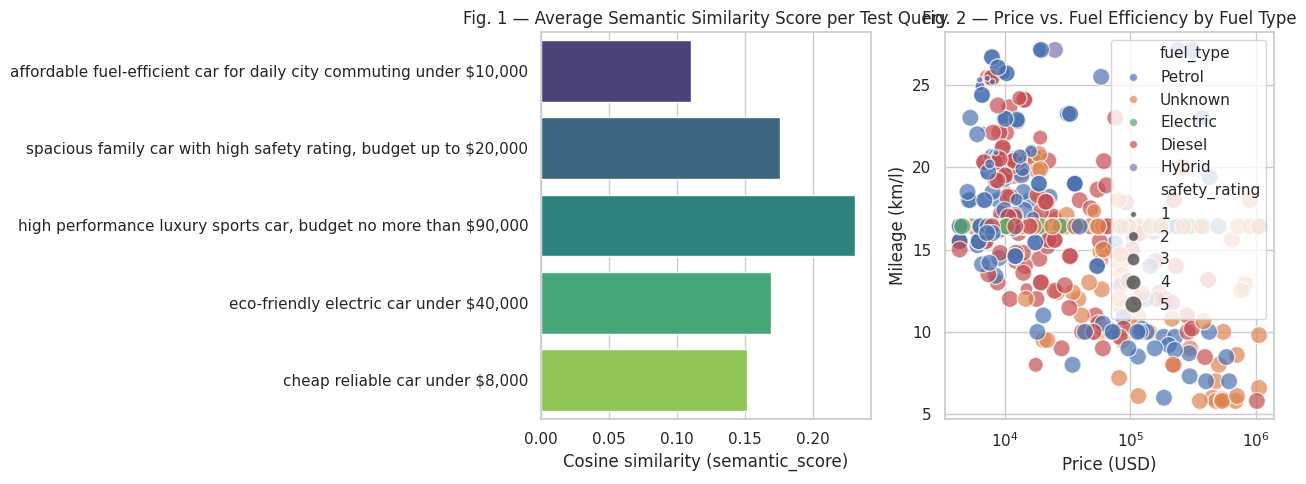

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=eval_df, y="query", x="avg_semantic_score", ax=axes[0], palette="viridis")
axes[0].set_title("Fig. 1 — Average Semantic Similarity Score per Test Query")
axes[0].set_xlabel("Cosine similarity (semantic_score)")
axes[0].set_ylabel("")

sns.scatterplot(
    data=df_clean, x="price_usd", y="mileage_kmpl", hue="fuel_type",
    size="safety_rating", sizes=(20, 150), alpha=0.7, ax=axes[1]
)
axes[1].set_title("Fig. 2 — Price vs. Fuel Efficiency by Fuel Type")
axes[1].set_xlabel("Price (USD)")
axes[1].set_ylabel("Mileage (km/l)")
axes[1].set_xscale("log")

plt.tight_layout()
plt.savefig("recommender_evaluation_figures.png", dpi=150)
plt.show()


/tmp/ipykernel_520/575092629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, y=top5["make"] + " " + top5["model"], x="final_score", palette="mako")


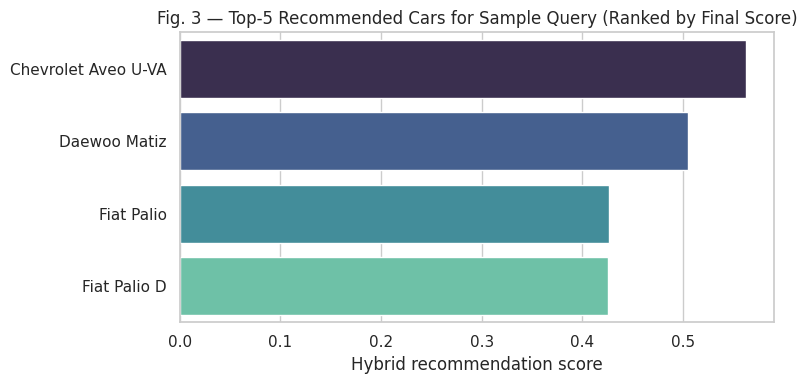

In [14]:
top5 = recs.copy()
plt.figure(figsize=(8, 4))
sns.barplot(data=top5, y=top5["make"] + " " + top5["model"], x="final_score", palette="mako")
plt.title("Fig. 3 — Top-5 Recommended Cars for Sample Query (Ranked by Final Score)")
plt.xlabel("Hybrid recommendation score")
plt.ylabel("")
plt.tight_layout()
plt.savefig("top5_recommendations.png", dpi=150)
plt.show()


## 13. Export Artifacts (for the GitHub Repository)

In [15]:
os.makedirs("outputs", exist_ok=True)
df_clean.to_csv("outputs/cars_clean.csv", index=False)
np.save("outputs/car_embeddings.npy", car_embeddings)
eval_df.to_csv("outputs/evaluation_results.csv", index=False)

print("Saved: outputs/cars_clean.csv, outputs/car_embeddings.npy, outputs/evaluation_results.csv")


Saved: outputs/cars_clean.csv, outputs/car_embeddings.npy, outputs/evaluation_results.csv


## 14. Conclusion

This notebook demonstrates a working hybrid NLP recommendation pipeline —
**Sentence-BERT semantic matching + rule-based constraint filtering** — running on a
**real, messy, scraped dataset of 504 cars**, including a documented data-repair step
for a genuine column-shift defect discovered during exploration.

**Key limitations** (detailed in the written report):
- No body-type/segment field in the source data — usage-based filtering (e.g. "SUV")
  relies only on semantic similarity, not a hard constraint
- ~28–64% missing rates on several specs (engine power, transmission, safety rating)
  required median/label imputation, which can blur true differences between cars
- Prices are in Indian Rupees converted at one approximate exchange rate; real-world
  deployment would need live rates and possibly multi-market pricing
- Evaluation is heuristic (constraint-satisfaction), not based on human relevance labels

**Next steps:** collect user feedback via the accompanying questionnaire to build a
relevance-labeled evaluation set, and enrich the dataset with a body-type/segment label
(e.g. inferred via a small classifier trained on car names, or joined from an external
taxonomy).
